# Load Dateset

In [2]:
import pandas as pd
import numpy as np

In [3]:
file_path = r"D:\Universitas Brawijaya_Roganda\BELAJAR_MANDIRI\DataScience\Project\StudentPerformanceFactors\dataset\Modeling1_StudentPerformanceFactors.csv"

df = pd.read_csv(file_path)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hours_Studied                   6607 non-null   int64  
 1   Attendance                      6607 non-null   int64  
 2   Parental_Involvement            6607 non-null   float64
 3   Access_to_Resources             6607 non-null   float64
 4   Sleep_Hours                     6607 non-null   int64  
 5   Previous_Scores                 6607 non-null   int64  
 6   Motivation_Level                6607 non-null   float64
 7   Tutoring_Sessions               6607 non-null   int64  
 8   Family_Income                   6607 non-null   float64
 9   Teacher_Quality                 6607 non-null   float64
 10  Peer_Influence                  6607 non-null   float64
 11  Physical_Activity               6607 non-null   int64  
 12  Parental_Education_Level        6607 non-null

In [5]:
# Feature Engineering
df['Study_Efficiency'] = df['Hours_Studied'] * df['Attendance'] / 100
df['Support_Score'] = df['Parental_Involvement'] + df['Access_to_Resources'] + df['Family_Income']
df['Score_Gap'] = df['Previous_Scores'] - df['Previous_Scores'].mean()
df['Total_Support_Hours'] = df['Tutoring_Sessions'] + df['Hours_Studied']

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hours_Studied                   6607 non-null   int64  
 1   Attendance                      6607 non-null   int64  
 2   Parental_Involvement            6607 non-null   float64
 3   Access_to_Resources             6607 non-null   float64
 4   Sleep_Hours                     6607 non-null   int64  
 5   Previous_Scores                 6607 non-null   int64  
 6   Motivation_Level                6607 non-null   float64
 7   Tutoring_Sessions               6607 non-null   int64  
 8   Family_Income                   6607 non-null   float64
 9   Teacher_Quality                 6607 non-null   float64
 10  Peer_Influence                  6607 non-null   float64
 11  Physical_Activity               6607 non-null   int64  
 12  Parental_Education_Level        6607 non-null

In [6]:
df.head(10)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,...,Gender_Male,School_Type_Public,Internet_Access_Yes,Extracurricular_Activities_Yes,Learning_Disabilities_Yes,Exam_Score,Study_Efficiency,Support_Score,Score_Gap,Total_Support_Hours
0,23,84,0.0,2.0,7,73,0.0,0,0.0,1.0,...,1.0,1.0,1.0,0.0,0.0,67,19.32,2.0,-2.070531,23
1,19,64,0.0,1.0,8,59,0.0,2,1.0,1.0,...,0.0,1.0,1.0,0.0,0.0,61,12.16,2.0,-16.070531,21
2,24,98,1.0,1.0,7,91,1.0,2,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,74,23.52,3.0,15.929469,26
3,29,89,0.0,1.0,8,98,1.0,1,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,71,25.81,2.0,22.929469,30
4,19,92,1.0,1.0,6,65,1.0,3,1.0,2.0,...,0.0,1.0,1.0,1.0,0.0,70,17.48,3.0,-10.070531,22
5,19,88,1.0,1.0,8,89,1.0,3,1.0,1.0,...,1.0,1.0,1.0,1.0,0.0,71,16.72,3.0,13.929469,22
6,29,84,1.0,0.0,7,68,0.0,1,0.0,1.0,...,1.0,0.0,1.0,1.0,0.0,67,24.36,1.0,-7.070531,30
7,25,78,0.0,2.0,6,50,1.0,1,2.0,2.0,...,1.0,1.0,1.0,1.0,0.0,66,19.50,4.0,-25.070531,26
8,17,94,1.0,2.0,6,80,2.0,0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,69,15.98,4.0,4.929469,17
9,23,98,1.0,1.0,8,71,1.0,0,2.0,2.0,...,1.0,1.0,1.0,1.0,0.0,72,22.54,4.0,-4.070531,23


# Modeling

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (5285, 23)
Test shape : (1322, 23)


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel='rbf'),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=200, max_depth=3, random_state=42)
}

In [11]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False).reset_index(drop=True)
print(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000665 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 565
[LightGBM] [Info] Number of data points in the train set: 5285, number of used features: 23
[LightGBM] [Info] Start training from score 67.214948
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

C:\Users\ASUS\AppData\Local\Temp\ipykernel_8492\2466364080.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="R2", y="Model", palette="coolwarm")


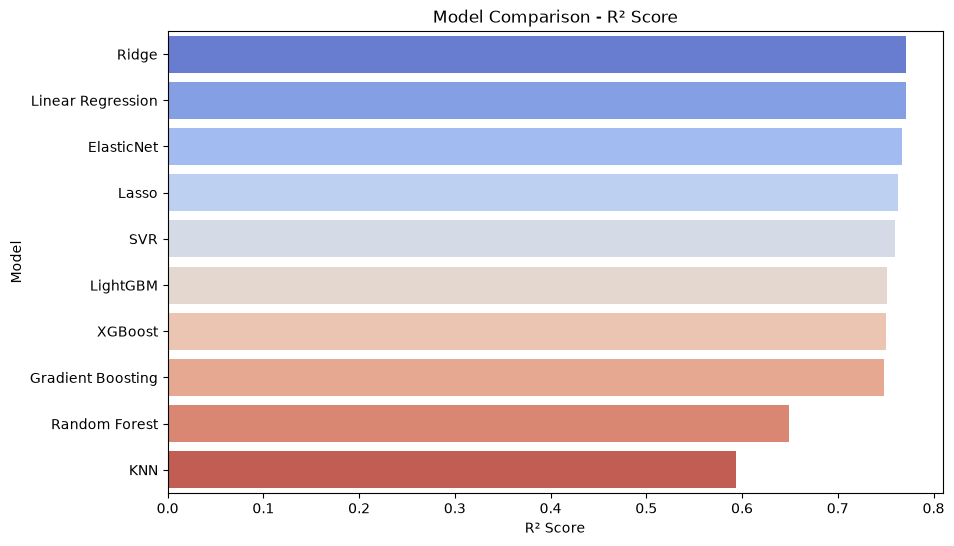

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x="R2", y="Model", palette="coolwarm")
plt.title("Model Comparison - R² Score")
plt.xlabel("R² Score")
plt.show()

In [13]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

print(f"Best model: {best_model_name}")

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(x=importances.values, y=importances.index)
    plt.title(f"Feature Importance ({best_model_name})")
    plt.show()
else:
    print("Model ini gak punya feature_importances_ (biasanya linear model), cek .coef_ sebagai gantinya.")

Best model: Ridge
Model ini gak punya feature_importances_ (biasanya linear model), cek .coef_ sebagai gantinya.


In [14]:
from sklearn.model_selection import GridSearchCV

param_grid_ridge = {'alpha': [0.01, 0.1, 1, 10, 100]}

grid_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

print("Best alpha (Ridge):", grid_ridge.best_params_)
print("Best CV R2:", grid_ridge.best_score_)

Best alpha (Ridge): {'alpha': 10}
Best CV R2: 0.7240499291650225


In [15]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [2, 3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_xgb.fit(X_train_scaled, y_train)

print("Best params (XGBoost):", grid_xgb.best_params_)
print("Best CV R2:", grid_xgb.best_score_)

Best params (XGBoost): {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.7}
Best CV R2: 0.7064661741256714


In [17]:
best_ridge = grid_ridge.best_estimator_
best_xgb = grid_xgb.best_estimator_

for name, model in [("Ridge (tuned)", best_ridge), ("XGBoost (tuned)", best_xgb)]:
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name} -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R2: {r2:.3f}")

Ridge (tuned) -> MAE: 0.449, RMSE: 1.799, R2: 0.771
XGBoost (tuned) -> MAE: 0.598, RMSE: 1.846, R2: 0.759
